# Phase 0

Charger la dataset

In [110]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Forme : (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Phase 1 

afficher la fonction 

In [179]:
def audit_qualite(df):
    """
    Affiche un rapport de santé du dataset :
    - dimensions ;
    - types des colonnes ;
    - pourcentage de valeurs manquantes ;
    - répartition de la cible Churn.
    """

    # 1. Afficher les dimensions
    print("DIMENSIONS ")
    print("Forme :", df.shape)
    print("Nombre de lignes :", df.shape[0])
    print("Nombre de colonnes :", df.shape[1])

    # 2. Afficher le type de chaque colonne
    print("\nTYPES DES COLONNES ")
    print(df.dtypes)

    # 3. Calculer le pourcentage de valeurs manquantes
    print("\n VALEURS MANQUANTES ")

    taux_manquants = (
        df.isna()                      
        .mean()                       
        .mul(100)                      
        .sort_values(ascending=False)  
    )

    # Compter les colonnes qui possèdent au moins un manque
    nombre_colonnes_manquantes = (taux_manquants > 0).sum()

    print(
        "Manquants détectés :",
        nombre_colonnes_manquantes,
        "colonne(s)"
    )

    print("\nPourcentage de valeurs manquantes par colonne :")
    print(taux_manquants.round(2))

    # 4. Vérifier que la colonne Churn existe
    print("\n RÉPARTITION DE CHURN ")

    if "Churn" not in df.columns:
        print("Erreur : la colonne Churn est absente.")
        return

    # 5. Compter les Yes et les No
    effectifs = df["Churn"].value_counts(dropna=False)

    # Calculer leurs pourcentages
    pourcentages = (
        df["Churn"]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
    )

    # Afficher chaque classe avec son nombre et son pourcentage
    for valeur, nombre in effectifs.items():

        if valeur == "No":
            nom_classe = "Non"
        elif valeur == "Yes":
            nom_classe = "Oui"
        else:
            nom_classe = str(valeur)

        print(
            f"Churn {nom_classe} : "
            f"{nombre} ({pourcentages[valeur]:.1f}%)"
        )

    # 6. Vérifier si la cible est déséquilibrée
    classe_majoritaire = pourcentages.idxmax()
    pourcentage_majoritaire = pourcentages.max()

    if len(pourcentages) == 1:
        print(
            "\nCas limite détecté : le dataset contient "
            "une seule classe de Churn."
        )

    elif pourcentage_majoritaire >= 70:
        print(
            "\nAttention : la cible est déséquilibrée."
        )
        print(
            f"La classe majoritaire '{classe_majoritaire}' représente "
            f"{pourcentage_majoritaire:.1f}% des données."
        )
        print(
            "L'accuracy seule pourra donc être trompeuse."
        )

    else:
        print("\nLa cible ne présente pas de fort déséquilibre.")

audit_qualite(df)


DIMENSIONS 
Forme : (7043, 21)
Nombre de lignes : 7043
Nombre de colonnes : 21

TYPES DES COLONNES 
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

 VALEURS MANQUANTES 
Manquants détectés : 0 colonne(s)

Pourcentage de valeurs manquantes par colonne :
customerID          0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0
StreamingMovies     0.0
S

## Les tests 

### Test 1 : Cas normal 

In [180]:

print("TEST 1 : DATASET COMPLET")


audit_qualite(df)


TEST 1 : DATASET COMPLET
DIMENSIONS 
Forme : (7043, 21)
Nombre de lignes : 7043
Nombre de colonnes : 21

TYPES DES COLONNES 
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

 VALEURS MANQUANTES 
Manquants détectés : 0 colonne(s)

Pourcentage de valeurs manquantes par colonne :
customerID          0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0


### Test : cas limite 

In [181]:

print("TEST 2 : UNE SEULE CLASSE")


df_une_classe = df[df["Churn"] == "Yes"].copy()

audit_qualite(df_une_classe)

TEST 2 : UNE SEULE CLASSE
DIMENSIONS 
Forme : (1869, 21)
Nombre de lignes : 1869
Nombre de colonnes : 21

TYPES DES COLONNES 
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

 VALEURS MANQUANTES 
Manquants détectés : 0 colonne(s)

Pourcentage de valeurs manquantes par colonne :
customerID          0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0

### Test : CAS ADVERSARIAL

In [182]:

print("TEST 3 : cas adversarial" )

df_adversarial = pd.DataFrame({
    "Churn": ["No"] * 73 + ["Yes"] * 27
})

audit_qualite(df_adversarial)

TEST 3 : cas adversarial
DIMENSIONS 
Forme : (100, 1)
Nombre de lignes : 100
Nombre de colonnes : 1

TYPES DES COLONNES 
Churn    object
dtype: object

 VALEURS MANQUANTES 
Manquants détectés : 0 colonne(s)

Pourcentage de valeurs manquantes par colonne :
Churn    0.0
dtype: float64

 RÉPARTITION DE CHURN 
Churn Non : 73 (73.0%)
Churn Oui : 27 (27.0%)

Attention : la cible est déséquilibrée.
La classe majoritaire 'No' représente 73.0% des données.
L'accuracy seule pourra donc être trompeuse.


# Phase 2 

### Observer le problème avant de réparer

In [183]:
# Vérification du type de la colonne TotalCharges

print("Type de TotalCharges :", df["TotalCharges"].dtype)

# On compte les valeurs qui contiennent uniquement des espaces
nombre_espaces = (
    df["TotalCharges"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Nombre d'espaces cachés :", nombre_espaces)


Type de TotalCharges : float64
Nombre d'espaces cachés : 0


### Créer la fonction de réparation 

In [184]:
def reparer_total_charges(df):
    """
    Convertit TotalCharges en numérique et traite les trous révélés.

    La fonction :
    - détecte les espaces cachés ;
    - vérifie les valeurs non numériques ;
    - convertit TotalCharges en float64 ;
    - remplace les valeurs manquantes par la médiane ;
    - renvoie le DataFrame réparé.
    """

    # Vérifier que la colonne existe
    if "TotalCharges" not in df.columns:
        raise ValueError("La colonne TotalCharges est absente.")

    # Faire une copie pour protéger le DataFrame original
    df_repare = df.copy()

    # Transformer temporairement la colonne en texte
    # et enlever les espaces autour des valeurs
    colonne_texte = (
        df_repare["TotalCharges"]
        .astype("string")
        .str.strip()
    )

    # Compter les chaînes vides
    nombre_espaces = colonne_texte.eq("").sum()

    print("Espaces cachés détectés :", nombre_espaces)

    # Remplacer les chaînes vides par de vraies valeurs manquantes
    colonne_texte = colonne_texte.replace("", pd.NA)

    # Tester la conversion en numérique
    # Les valeurs impossibles deviennent NaN
    colonne_numerique = pd.to_numeric(
        colonne_texte,
        errors="coerce"
    )

    # Chercher les valeurs non vides qui n'ont pas pu être converties
    masque_corruption = (
        colonne_texte.notna()
        & colonne_numerique.isna()
    )

    valeurs_corrompues = (
        colonne_texte[masque_corruption]
        .drop_duplicates()
        .tolist()
    )

    # Cas limite : aucune valeur n'est numérique
    if colonne_numerique.notna().sum() == 0:
        raise ValueError(
            "Conversion refusée : la colonne est entièrement non numérique."
        )

    # Refuser les valeurs corrompues comme 29,90
    if len(valeurs_corrompues) > 0:
        raise ValueError(
            "Conversion refusée. Valeurs non numériques détectées : "
            f"{valeurs_corrompues}"
        )

    # Compter les trous apparus après conversion
    nombre_trous = colonne_numerique.isna().sum()

    print("Trous révélés après conversion :", nombre_trous)

    # Calculer la médiane
    mediane = colonne_numerique.median()

    print("Médiane utilisée :", mediane)

    # Remplacer les trous par la médiane
    colonne_numerique = colonne_numerique.fillna(mediane)

    # Enregistrer la colonne réparée en float64
    df_repare["TotalCharges"] = colonne_numerique.astype("float64")

    print("Type après conversion :", df_repare["TotalCharges"].dtype)
    print(
        "Valeurs manquantes restantes :",
        df_repare["TotalCharges"].isna().sum()
    )

    return df_repare

df_repare = reparer_total_charges(df)

Espaces cachés détectés : 0
Trous révélés après conversion : 0
Médiane utilisée : 1397.475
Type après conversion : float64
Valeurs manquantes restantes : 0


### HAPPY PATH : dataset complete

In [185]:
# HAPPY PATH : réparation du vrai dataset

df_repare = reparer_total_charges(df)

print("\nVérifications finales :")
print("Type :", df_repare["TotalCharges"].dtype)
print(
    "Nombre de valeurs manquantes :",
    df_repare["TotalCharges"].isna().sum()
)
print("Dimensions :", df_repare.shape)

assert df_repare["TotalCharges"].dtype == "float64"
assert df_repare["TotalCharges"].isna().sum() == 0
assert df_repare.shape == df.shape

print("\nHappy path validé.")

Espaces cachés détectés : 0
Trous révélés après conversion : 0
Médiane utilisée : 1397.475
Type après conversion : float64
Valeurs manquantes restantes : 0

Vérifications finales :
Type : float64
Nombre de valeurs manquantes : 0
Dimensions : (7043, 21)

Happy path validé.


afficher des valeurs réparés : 

In [186]:
df_repare[["TotalCharges"]].head(10)

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
5,820.50
6,1949.40
7,301.90
8,3046.05
9,3487.95


### Edge case : colonne entièrement non numérique

In [187]:
# EDGE CASE : colonne contenant uniquement du texte

df_texte = pd.DataFrame({
    "TotalCharges": [
        "bonjour",
        "texte",
        "erreur"
    ]
})

try:
    reparer_total_charges(df_texte)

except ValueError as erreur:
    print("Erreur correctement détectée :")
    print(erreur)

Espaces cachés détectés : 0
Erreur correctement détectée :
Conversion refusée : la colonne est entièrement non numérique.


### Fonction pour détecter une corruption avant conversion

In [188]:
def detecter_corruption_numerique(df, colonne):
    """
    Repère les valeurs non vides qui ne peuvent pas
    être converties en nombres.
    """

    # Vérifier que la colonne existe
    if colonne not in df.columns:
        raise ValueError(f"La colonne {colonne} est absente.")

    # Transformer en texte et retirer les espaces
    colonne_texte = (
        df[colonne]
        .astype("string")
        .str.strip()
    )

    # Remplacer les chaînes vides par des valeurs manquantes
    colonne_texte = colonne_texte.replace("", pd.NA)

    # Tester la conversion sans modifier le DataFrame
    test_conversion = pd.to_numeric(
        colonne_texte,
        errors="coerce"
    )

    # Repérer les valeurs présentes mais impossibles à convertir
    masque_corruption = (
        colonne_texte.notna()
        & test_conversion.isna()
    )

    valeurs_corrompues = (
        colonne_texte[masque_corruption]
        .drop_duplicates()
        .tolist()
    )

    if len(valeurs_corrompues) == 0:
        print(f"Aucune corruption détectée dans {colonne}.")
    else:
        print(
            f"Valeurs corrompues détectées dans {colonne} :",
            valeurs_corrompues
        )

    return valeurs_corrompues


df_repare = reparer_total_charges(df)


Espaces cachés détectés : 0
Trous révélés après conversion : 0
Médiane utilisée : 1397.475
Type après conversion : float64
Valeurs manquantes restantes : 0


### Adversarial : tester 29,90

In [189]:
# ADVERSARIAL 

df_corrompu = pd.DataFrame({
    "MonthlyCharges": [
        "19.90",
        "29,90",
        "49.50"
    ]
})

valeurs_anormales = detecter_corruption_numerique(
    df_corrompu,
    "MonthlyCharges"
)

assert "29,90" in valeurs_anormales

print("Test adversarial validé.")
detecter_corruption_numerique(df, "MonthlyCharges")

Valeurs corrompues détectées dans MonthlyCharges : ['29,90']
Test adversarial validé.
Aucune corruption détectée dans MonthlyCharges.


[]

Conserver le dataset réparé

In [191]:
df = df_repare
print("Forme :", df.shape)
print("Type de TotalCharges :", df["TotalCharges"].dtype)

Forme : (7043, 21)
Type de TotalCharges : float64


# Phase 3 : 

### Observer les colonnes catégorielles

In [192]:
# Repérer les colonnes contenant du texte

colonnes_categorielles = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(
    "Nombre de colonnes catégorielles :",
    len(colonnes_categorielles)
)

print("\nColonnes catégorielles :")

for colonne in colonnes_categorielles:
    print(
        f"- {colonne} : "
        f"{df[colonne].nunique(dropna=False)} modalité(s)"
    )


Nombre de colonnes catégorielles : 17

Colonnes catégorielles :
- customerID : 7043 modalité(s)
- gender : 2 modalité(s)
- Partner : 2 modalité(s)
- Dependents : 2 modalité(s)
- PhoneService : 2 modalité(s)
- MultipleLines : 3 modalité(s)
- InternetService : 3 modalité(s)
- OnlineSecurity : 3 modalité(s)
- OnlineBackup : 3 modalité(s)
- DeviceProtection : 3 modalité(s)
- TechSupport : 3 modalité(s)
- StreamingTV : 3 modalité(s)
- StreamingMovies : 3 modalité(s)
- Contract : 3 modalité(s)
- PaperlessBilling : 2 modalité(s)
- PaymentMethod : 4 modalité(s)
- Churn : 2 modalité(s)


### Observer les modalités de chaque colonne

In [193]:
# Afficher les différentes modalités des colonnes catégorielles

for colonne in colonnes_categorielles:

    print(f"\n{colonne} :")

    valeurs = df[colonne].dropna().unique()

    # On évite d'afficher les 7043 customerID
    if len(valeurs) <= 10:
        print(valeurs)
    else:
        print(
            f"{len(valeurs)} valeurs différentes "
            "(liste non affichée)"
        )


customerID :
7043 valeurs différentes (liste non affichée)

gender :
['Female' 'Male']

Partner :
['Yes' 'No']

Dependents :
['No' 'Yes']

PhoneService :
['No' 'Yes']

MultipleLines :
['No phone service' 'No' 'Yes']

InternetService :
['DSL' 'Fiber optic' 'No']

OnlineSecurity :
['No' 'Yes' 'No internet service']

OnlineBackup :
['Yes' 'No' 'No internet service']

DeviceProtection :
['No' 'Yes' 'No internet service']

TechSupport :
['No' 'Yes' 'No internet service']

StreamingTV :
['No' 'Yes' 'No internet service']

StreamingMovies :
['No' 'Yes' 'No internet service']

Contract :
['Month-to-month' 'One year' 'Two year']

PaperlessBilling :
['Yes' 'No']

PaymentMethod :
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn :
['No' 'Yes']


### Mesurer le problème de customerID

In [194]:
# Compter les identifiants différents

nombre_lignes = df.shape[0]
nombre_identifiants = df["customerID"].nunique()

print("Nombre de clients :", nombre_lignes)
print(
    "Nombre de customerID différents :",
    nombre_identifiants
)

print(
    "\nAvec un One-Hot Encoding, customerID créerait",
    nombre_identifiants,
    "colonnes."
)

Nombre de clients : 7043
Nombre de customerID différents : 7043

Avec un One-Hot Encoding, customerID créerait 7043 colonnes.


### Créer la fonction encoder_features

In [223]:
df_phase3 = encoder_features(df)

print("Dimensions de df_phase3 :", df_phase3.shape)

print(
    "Colonnes non numériques :",
    df_phase3.select_dtypes(exclude=["number"]).columns.tolist()
)

print(
    "customerID présent :",
    "customerID" in df_phase3.columns
)

    
    # 2. Repérer les colonnes catégorielles
    

    colonnes_texte = df_encode.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # Liste qui contiendra les colonnes Yes/No
    colonnes_yes_no = []

    for colonne in colonnes_texte:

        # Récupérer les valeurs différentes
        modalites = set(
            df_encode[colonne]
            .dropna()
            .unique()
        )

        # Vérifier que la colonne contient uniquement Yes et No
        if modalites == {"Yes", "No"}:
            colonnes_yes_no.append(colonne)

    print(
        "\nColonnes Yes/No détectées :",
        colonnes_yes_no
    )

    
    # 3. Transformer Yes/No en 0/1
    

    for colonne in colonnes_yes_no:

        df_encode[colonne] = df_encode[colonne].map({
            "No": 0,
            "Yes": 1
        })

    
    # 4. Transformer gender en 0/1
    

    if "gender" in df_encode.columns:

        df_encode["gender"] = df_encode["gender"].map({
            "Female": 0,
            "Male": 1
        })

        print("gender encodé : Female = 0, Male = 1")

    
    # 5. Repérer les colonnes catégorielles restantes
    
    colonnes_nominales = df_encode.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    print("\nColonnes encodées en One-Hot :")

    for colonne in colonnes_nominales:
        print("-", colonne)

    
    # 6. Appliquer le One-Hot Encoding
    

    df_encode = pd.get_dummies(
        df_encode,
        columns=colonnes_nominales,
        drop_first=False,
        dtype=int
    )

    
    # 7. Vérifier qu'il ne reste aucune colonne textuelle
    
    colonnes_non_numeriques = df_encode.select_dtypes(
        exclude=["number"]
    ).columns.tolist()

    if len(colonnes_non_numeriques) > 0:

        raise ValueError(
            "Certaines colonnes ne sont pas numériques : "
            f"{colonnes_non_numeriques}"
        )

    print("\n APRÈS ENCODAGE")
    print("Dimensions :", df_encode.shape)
    print("Toutes les colonnes sont numériques.")

    return df_encode

df_encode = encoder_features(df)

IndentationError: unexpected indent (3108721467.py, line 19)

In [224]:
display(df_encode.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0


### Happy path : vérifier que tout est numérique

In [225]:
colonnes_texte_restantes = df_encode.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(
    "Colonnes textuelles restantes :",
    colonnes_texte_restantes
)

print(
    "Nombre de lignes avant encodage :",
    df.shape[0]
)

print(
    "Nombre de lignes après encodage :",
    df_encode.shape[0]
)

assert "customerID" not in df_encode.columns
assert len(colonnes_texte_restantes) == 0
assert df_encode.shape[0] == df.shape[0]

print("\nHappy path validé.")
print("Toutes les colonnes sont numériques.")
print("Aucune ligne n'a été supprimée.")

Colonnes textuelles restantes : []
Nombre de lignes avant encodage : 7043
Nombre de lignes après encodage : 7043

Happy path validé.
Toutes les colonnes sont numériques.
Aucune ligne n'a été supprimée.


### Edge case — La colonne Contract

In [226]:
print("Modalités originales de Contract :")

print(
    df["Contract"]
    .value_counts()
)


Modalités originales de Contract :
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


### Cas adversarial — Catégorie très rare

In [227]:
df_categorie_rare = pd.DataFrame({
    "PaymentMethod": [
        "Credit card",
        "Credit card",
        "Credit card",
        "Paiement exceptionnel"
    ]
})

display(df_categorie_rare)

,PaymentMethod
0,Credit card
1,Credit card
2,Credit card
3,Paiement exceptionnel


In [228]:
df_rare_encode = pd.get_dummies(
    df_categorie_rare,
    columns=["PaymentMethod"],
    drop_first=False,
    dtype=int
)

display(df_rare_encode)

,PaymentMethod_Credit card,PaymentMethod_Paiement exceptionnel
0,1,0
1,1,0
2,1,0
3,0,1


In [229]:
colonne_rare = "PaymentMethod_Paiement exceptionnel"

print(
    "Nombre de lignes contenant la catégorie rare :",
    df_rare_encode[colonne_rare].sum()
)

assert colonne_rare in df_rare_encode.columns
assert df_rare_encode[colonne_rare].sum() == 1

print("Test de la catégorie rare validé.")

Nombre de lignes contenant la catégorie rare : 1
Test de la catégorie rare validé.


### Cas adversarial — Explosion de customerID

In [230]:
# Nombre théorique de colonnes One-Hot pour customerID

nombre_colonnes_customer_id = (
    df["customerID"].nunique()
)

print(
    "Nombre de colonnes créées si customerID était encodé :",
    nombre_colonnes_customer_id
)

print(
    "Nombre total approximatif de colonnes obtenues :",
    df_encode.shape[1] + nombre_colonnes_customer_id
)

Nombre de colonnes créées si customerID était encodé : 7043
Nombre total approximatif de colonnes obtenues : 7084


In [231]:
df_phase3 = df_encode.copy()


print("Dimensions :", df_phase3.shape)
print(
    "Colonnes textuelles restantes :",
    df_phase3.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

Dimensions : (7043, 41)
Colonnes textuelles restantes : []


vérification 

# Phase 4 

In [232]:
def detecter_outliers_iqr(df, colonne):
    """
    Renvoie les bornes IQR et le nombre d'outliers
    d'une colonne numérique.
    """

    # Premier et troisième quartiles
    q1 = df[colonne].quantile(0.25)
    q3 = df[colonne].quantile(0.75)

    # Écart interquartile
    iqr = q3 - q1

    # Bornes de détection
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr

    # Valeurs situées hors des bornes
    masque_outliers = (
        (df[colonne] < borne_basse)
        | (df[colonne] > borne_haute)
    )

    nombre_outliers = masque_outliers.sum()

    return borne_basse, borne_haute, nombre_outliers

In [233]:
colonnes_numeriques = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for colonne in colonnes_numeriques:

    borne_basse, borne_haute, nombre_outliers = (
        detecter_outliers_iqr(df, colonne)
    )

    print(f"\nColonne : {colonne}")
    print("Borne basse :", round(borne_basse, 2))
    print("Borne haute :", round(borne_haute, 2))
    print("Nombre d'outliers :", nombre_outliers)


Colonne : tenure
Borne basse : -60.0
Borne haute : 124.0
Nombre d'outliers : 0

Colonne : MonthlyCharges
Borne basse : -46.02
Borne haute : 171.38
Nombre d'outliers : 0

Colonne : TotalCharges
Borne basse : -4674.34
Borne haute : 8863.16
Nombre d'outliers : 0


### visualisation 

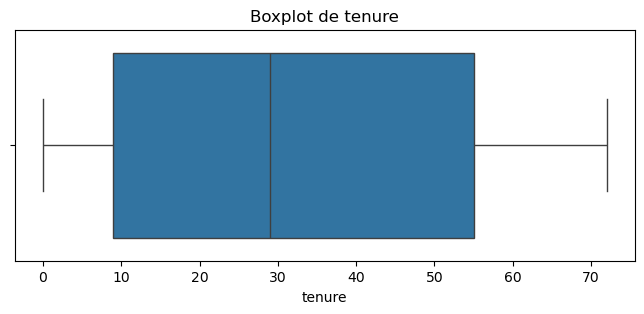

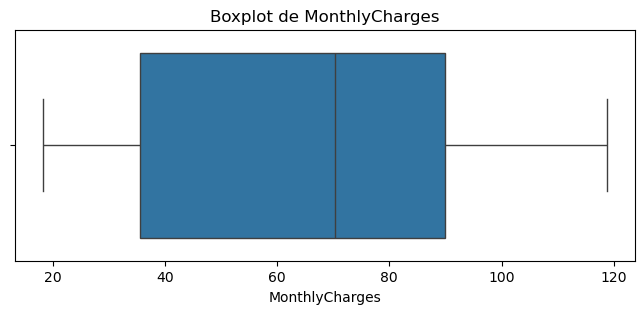

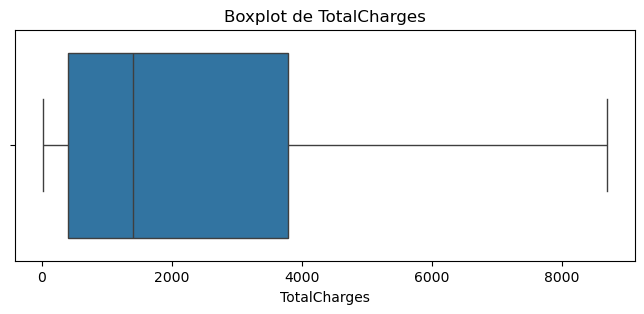

In [234]:
import matplotlib.pyplot as plt
import seaborn as sns

for colonne in colonnes_numeriques:

    plt.figure(figsize=(8, 3))

    sns.boxplot(x=df[colonne])

    plt.title(f"Boxplot de {colonne}")
    plt.xlabel(colonne)

    plt.show()

### Vérification d’une colonne sans outlier

In [235]:
borne_basse, borne_haute, nombre_outliers = (
    detecter_outliers_iqr(df, "tenure")
)

print("Colonne testée : tenure")
print("Borne basse :", round(borne_basse, 2))
print("Borne haute :", round(borne_haute, 2))
print("Nombre d'outliers :", nombre_outliers)

if nombre_outliers == 0:
    print("La fonction renvoie bien 0 sans provoquer d'erreur.")

Colonne testée : tenure
Borne basse : -60.0
Borne haute : 124.0
Nombre d'outliers : 0
La fonction renvoie bien 0 sans provoquer d'erreur.


### Repérer toutes les lignes contenant un outlier

In [236]:
masque_total_outliers = pd.Series(
    False,
    index=df.index
)

for colonne in colonnes_numeriques:

    borne_basse, borne_haute, nombre_outliers = (
        detecter_outliers_iqr(df, colonne)
    )

    masque_colonne = (
        (df[colonne] < borne_basse)
        | (df[colonne] > borne_haute)
    )

    masque_total_outliers = (
        masque_total_outliers
        | masque_colonne
    )

print(
    "Nombre de clients contenant au moins un outlier :",
    masque_total_outliers.sum()
)

Nombre de clients contenant au moins un outlier : 0


### Mesurer les clients Churn perdus

In [237]:
# Nombre total de clients ayant résilié
nombre_churn_total = (df["Churn"] == "Yes").sum()

# Clients ayant résilié parmi les lignes outliers
nombre_churn_perdus = (
    masque_total_outliers
    & (df["Churn"] == "Yes")
).sum()

# Pourcentage de churners perdus
if nombre_churn_total > 0:

    pourcentage_churn_perdu = (
        nombre_churn_perdus
        / nombre_churn_total
        * 100
    )

else:
    pourcentage_churn_perdu = 0

print("Nombre total de churners :", nombre_churn_total)

print(
    "Churners perdus en supprimant les outliers :",
    nombre_churn_perdus
)

print(
    "Pourcentage de churners perdus :",
    round(pourcentage_churn_perdu, 2),
    "%"
)

if pourcentage_churn_perdu >= 5:
    print(
        "Alerte : la suppression ferait perdre "
        "au moins 5 % des résiliations."
    )

Nombre total de churners : 1869
Churners perdus en supprimant les outliers : 0
Pourcentage de churners perdus : 0.0 %


# Phase 5 

### Calculer la matrice de corrélation

In [238]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [239]:
colonnes_multicolinearite = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print("Colonnes analysées :")
print(colonnes_multicolinearite)
matrice_correlation = df[
    colonnes_multicolinearite
].corr()

print("Matrice de corrélation :")

display(matrice_correlation)

Colonnes analysées :
['tenure', 'MonthlyCharges', 'TotalCharges']
Matrice de corrélation :


,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.825464
MonthlyCharges,0.247900,1.000000,0.650864
TotalCharges,0.825464,0.650864,1.000000


### Afficher la heatmap

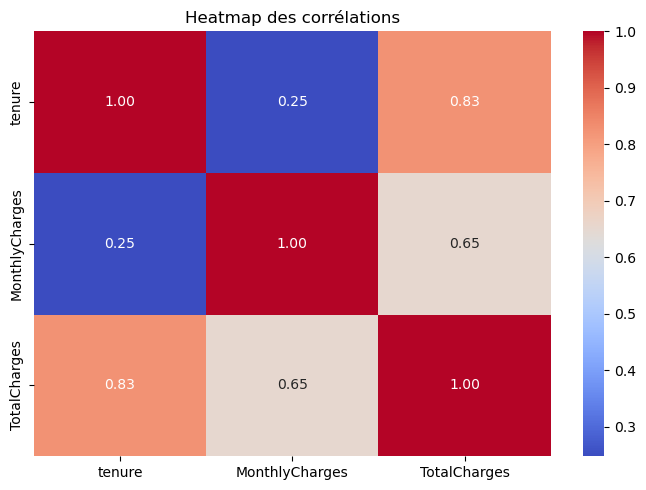

In [240]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    matrice_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Heatmap des corrélations")
plt.tight_layout()
plt.show()

### Calcul des VIF

In [241]:
def calculer_vif(df, colonnes):
    

    # Sélectionner les colonnes demandées
    donnees = df[colonnes].dropna().astype(float)

    # Ajouter une constante
    donnees_avec_constante = add_constant(
        donnees,
        has_constant="add"
    )

    resultats = []

    # Gérer les avertissements liés aux VIF infinis
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        for indice, colonne in enumerate(
            colonnes,
            start=1
        ):

            try:
                valeur_vif = variance_inflation_factor(
                    donnees_avec_constante.values,
                    indice
                )

            except Exception:
                valeur_vif = np.inf

            resultats.append({
                "Variable": colonne,
                "VIF": valeur_vif
            })

    tableau_vif = pd.DataFrame(resultats)

    return tableau_vif


### Happy path : calculer et afficher les VIF

In [242]:
vif_avant = calculer_vif(
    df,
    colonnes_multicolinearite
)

print("VIF avant suppression de TotalCharges :")

display(vif_avant)

VIF avant suppression de TotalCharges :


,Variable,VIF
0,tenure,5.769167
1,MonthlyCharges,3.189082
2,TotalCharges,9.394268


#### Afficher les VIF supérieurs à 5

In [243]:
vif_eleves_avant = vif_avant[
    vif_avant["VIF"] > 5
]

print("Variables avec un VIF supérieur à 5 :")

if vif_eleves_avant.empty:
    print("Aucune variable ne dépasse 5.")
else:
    display(vif_eleves_avant)

Variables avec un VIF supérieur à 5 :


,Variable,VIF
0,tenure,5.769167
2,TotalCharges,9.394268


### Edge case : deux colonnes identiques

In [244]:
df_duplique = df.copy()

df_duplique["tenure_copie"] = (
    df_duplique["tenure"]
)

print(
    df_duplique[
        ["tenure", "tenure_copie"]
    ].head()
)

   tenure  tenure_copie
0       1             1
1      34            34
2       2             2
3      45            45
4       2             2


#### Calculer le VIF des deux colonnes identiques

In [245]:
vif_duplique = calculer_vif(
    df_duplique,
    [
        "tenure",
        "tenure_copie"
    ]
)

print(
    "VIF de deux colonnes parfaitement identiques :"
)

display(vif_duplique)

VIF de deux colonnes parfaitement identiques :


,Variable,VIF
0,tenure,inf
1,tenure_copie,inf


### Vérifier l’information de TotalCharges

In [246]:
total_estime = (
    df["tenure"]
    * df["MonthlyCharges"]
)

correlation_total_estime = (
    df["TotalCharges"]
    .corr(total_estime)
)

print(
    "Corrélation entre TotalCharges et "
    "tenure × MonthlyCharges :",
    round(correlation_total_estime, 3)
)

Corrélation entre TotalCharges et tenure × MonthlyCharges : 0.999


### Supprimer TotalCharges

In [250]:
df_phase5 = df_phase3.drop(
    columns=["TotalCharges"]
).copy()

print("Dimensions de df_phase5 :", df_phase5.shape)

print(
    "TotalCharges présente :",
    "TotalCharges" in df_phase5.columns
)

Dimensions de df_phase5 : (7043, 40)
TotalCharges présente : False


### Recalculer les VIF après suppression

In [251]:
colonnes_apres_suppression = [
    "tenure",
    "MonthlyCharges"
]

vif_apres = calculer_vif(
    df_sans_total_charges,
    colonnes_apres_suppression
)

print("VIF après suppression de TotalCharges :")

display(vif_apres)

VIF après suppression de TotalCharges :


,Variable,VIF
0,tenure,1.065478
1,MonthlyCharges,1.065478


### Comparer les VIF avant et après

In [252]:
print("Avant suppression :")
display(vif_avant)

print("Après suppression :")
display(vif_apres)

Avant suppression :


,Variable,VIF
0,tenure,5.769167
1,MonthlyCharges,3.189082
2,TotalCharges,9.394268


Après suppression :


,Variable,VIF
0,tenure,1.065478
1,MonthlyCharges,1.065478


#### Interpretation : 

Si les VIF diminuent, cela signifie que la suppression de TotalCharges a réduit la multicolinéarité.

# Phase 6 

In [260]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

def features_discriminantes(df, cible="Churn"):
    

    # Vérifier que la cible existe
    if cible not in df.columns:
        raise ValueError(
            f"La colonne cible '{cible}' est absente."
        )

    # Vérifier que toutes les colonnes sont numériques
    colonnes_non_numeriques = df.select_dtypes(
        exclude=["number"]
    ).columns.tolist()

    if len(colonnes_non_numeriques) > 0:
        raise TypeError(
            "Certaines colonnes ne sont pas numériques : "
            f"{colonnes_non_numeriques}"
        )

    # Séparer les variables explicatives et la cible
    X = df.drop(columns=[cible]).copy()
    y = df[cible].copy()

    # Vérifier que customerID n'a pas été conservé
    colonnes_identifiants = [
        colonne
        for colonne in X.columns
        if colonne == "customerID"
        or colonne.startswith("customerID_")
    ]

    if len(colonnes_identifiants) > 0:
        raise ValueError(
            "Un identifiant customerID est encore présent."
        )

    
    # MÉTHODE 1 : CORRÉLATION AVEC LA CIBLE
    

    correlations = (
        X.corrwith(y)
        .abs()
        .fillna(0)
        .sort_values(ascending=False)
    )

    classement_correlation = (
        correlations
        .reset_index()
    )

    classement_correlation.columns = [
        "Variable",
        "Corrélation absolue"
    ]

    
    # MÉTHODE 2 : IMPORTANCE RANDOM FOREST
    

    modele_rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    modele_rf.fit(X, y)

    classement_rf = pd.DataFrame({
        "Variable": X.columns,
        "Importance Random Forest": modele_rf.feature_importances_
    })

    classement_rf = classement_rf.sort_values(
        by="Importance Random Forest",
        ascending=False
    ).reset_index(drop=True)

    
    # AFFICHER LES DEUX TOP 10 CÔTE À CÔTE
    
    top10_correlation = classement_correlation.head(10)
    top10_rf = classement_rf.head(10)

    comparaison = pd.concat(
        [
            top10_correlation.add_prefix("Corrélation - "),
            top10_rf.add_prefix("Random Forest - ")
        ],
        axis=1
    )

    print("Top 10 des variables les plus prédictives :")

    display(comparaison)

    return classement_correlation, classement_rf



In [262]:
classement_correlation, classement_rf = features_discriminantes(
    df_phase5,
    cible="Churn"
)

Top 10 des variables les plus prédictives :


,Corrélation - Variable,Corrélation - Corrélation absolue,Random Forest - Variable,Random Forest - Importance Random Forest
0,Contract_Month-to-month,0.405103,tenure,0.192591
1,tenure,0.352229,MonthlyCharges,0.183527
2,OnlineSecurity_No,0.342637,Contract_Month-to-month,0.091756
3,TechSupport_No,0.337281,OnlineSecurity_No,0.038519
4,InternetService_Fiber optic,0.308020,Contract_Two year,0.033324
5,Contract_Two year,0.302253,gender,0.030503
6,PaymentMethod_Electronic check,0.301919,TechSupport_No,0.028337
7,OnlineBackup_No,0.268005,PaymentMethod_Electronic check,0.026661
8,DeviceProtection_No,0.252481,PaperlessBilling,0.026651
9,InternetService_No,0.227890,InternetService_Fiber optic,0.025338


### Comparer les podiums

In [263]:
podium_correlation = (
    classement_correlation
    .head(3)["Variable"]
    .tolist()
)

podium_rf = (
    classement_rf
    .head(3)["Variable"]
    .tolist()
)

variables_communes = set(
    podium_correlation
).intersection(podium_rf)

print("Podium corrélation :", podium_correlation)
print("Podium Random Forest :", podium_rf)

print(
    "Variables communes aux deux podiums :",
    list(variables_communes)
)

Podium corrélation : ['Contract_Month-to-month', 'tenure', 'OnlineSecurity_No']
Podium Random Forest : ['tenure', 'MonthlyCharges', 'Contract_Month-to-month']
Variables communes aux deux podiums : ['Contract_Month-to-month', 'tenure']


### Happy path — Vérifier Contract et tenure

In [264]:


classement_correlation_rangs = (
    classement_correlation.copy()
)

classement_correlation_rangs[
    "Rang corrélation"
] = classement_correlation_rangs.index + 1


classement_rf_rangs = classement_rf.copy()

classement_rf_rangs[
    "Rang Random Forest"
] = classement_rf_rangs.index + 1


# Rassembler les deux classements

classement_complet = pd.merge(
    classement_correlation_rangs,
    classement_rf_rangs,
    on="Variable"
)

# Garder tenure et les colonnes Contract

verification_contract = classement_complet[
    (classement_complet["Variable"] == "tenure")
    | (
        classement_complet["Variable"]
        .str.startswith("Contract_")
    )
]

display(verification_contract)

,Variable,Corrélation absolue,Rang corrélation,Importance Random Forest,Rang Random Forest
0,Contract_Month-to-month,0.405103,1,0.091756,3
1,tenure,0.352229,2,0.192591,1
5,Contract_Two year,0.302253,6,0.033324,5
18,Contract_One year,0.177820,19,0.014359,16


#### Vérifier leur présence dans les top 10

In [265]:
top10_corr_variables = set(
    classement_correlation.head(10)["Variable"]
)

top10_rf_variables = set(
    classement_rf.head(10)["Variable"]
)

contract_dans_correlation = any(
    variable.startswith("Contract_")
    for variable in top10_corr_variables
)

contract_dans_rf = any(
    variable.startswith("Contract_")
    for variable in top10_rf_variables
)

print(
    "Une variable Contract est dans le top 10 corrélation :",
    contract_dans_correlation
)

print(
    "Une variable Contract est dans le top 10 Random Forest :",
    contract_dans_rf
)

Une variable Contract est dans le top 10 corrélation : True
Une variable Contract est dans le top 10 Random Forest : True


### Edge case — Variable quasi constante

In [266]:
df_quasi_constant = df_phase5.copy()

# La colonne contient presque uniquement des zéros
df_quasi_constant["variable_quasi_constante"] = 0

# Une seule ligne contient 1
df_quasi_constant.loc[
    df_quasi_constant.index[0],
    "variable_quasi_constante"
] = 1

print(
    df_quasi_constant[
        "variable_quasi_constante"
    ].value_counts()
)

variable_quasi_constante
0    7042
1       1
Name: count, dtype: int64


#### Mesurer son pouvoir prédictif

In [267]:
X_quasi = df_quasi_constant.drop(
    columns=["Churn"]
)

y_quasi = df_quasi_constant["Churn"]

# Corrélation
correlation_quasi = abs(
    X_quasi["variable_quasi_constante"]
    .corr(y_quasi)
)

# Random Forest
modele_quasi = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

modele_quasi.fit(X_quasi, y_quasi)

importances_quasi = pd.Series(
    modele_quasi.feature_importances_,
    index=X_quasi.columns
).sort_values(ascending=False)

importance_quasi = importances_quasi[
    "variable_quasi_constante"
]

rang_quasi = (
    importances_quasi.index.tolist()
    .index("variable_quasi_constante")
    + 1
)

print(
    "Corrélation de la variable quasi constante :",
    correlation_quasi
)

print(
    "Importance Random Forest :",
    importance_quasi
)

print(
    "Rang dans le classement Random Forest :",
    rang_quasi,
    "sur",
    len(importances_quasi)
)

Corrélation de la variable quasi constante : 0.007162150259642802
Importance Random Forest : 0.00010105103102163682
Rang dans le classement Random Forest : 40 sur 40


#### Vérifier l’absence de customerID

In [268]:
colonnes_customer_id = [
    colonne
    for colonne in df_phase5.columns
    if colonne == "customerID"
    or colonne.startswith("customerID_")
]

print(
    "Colonnes liées à customerID :",
    colonnes_customer_id
)

assert len(colonnes_customer_id) == 0

print("Aucun identifiant n'est utilisé comme variable prédictive.")

Colonnes liées à customerID : []
Aucun identifiant n'est utilisé comme variable prédictive.


### Adversarial — Information mutuelle et corrélation

#### Calculer l’information mutuelle

In [269]:
X = df_phase5.drop(columns=["Churn"])
y = df_phase5["Churn"]

valeurs_information_mutuelle = mutual_info_classif(
    X,
    y,
    random_state=42
)

classement_information_mutuelle = pd.DataFrame({
    "Variable": X.columns,
    "Information mutuelle": valeurs_information_mutuelle
})

classement_information_mutuelle = (
    classement_information_mutuelle
    .sort_values(
        by="Information mutuelle",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 10 selon l'information mutuelle :")

display(
    classement_information_mutuelle.head(10)
)

Top 10 selon l'information mutuelle :


,Variable,Information mutuelle
0,Contract_Month-to-month,0.100353
1,tenure,0.072782
2,TechSupport_No,0.071922
3,OnlineSecurity_No,0.064039
4,Contract_Two year,0.054594
5,InternetService_Fiber optic,0.048003
6,PaymentMethod_Electronic check,0.046406
7,MonthlyCharges,0.045232
8,InternetService_No,0.037311
9,DeviceProtection_No,0.035688


#### Comparer avec la corrélation

In [270]:
comparaison_mi = pd.merge(
    classement_correlation,
    classement_information_mutuelle,
    on="Variable"
)

# Ajouter les rangs
comparaison_mi["Rang corrélation"] = (
    comparaison_mi["Corrélation absolue"]
    .rank(
        ascending=False,
        method="min"
    )
)

comparaison_mi["Rang information mutuelle"] = (
    comparaison_mi["Information mutuelle"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Un résultat positif indique qu'une variable
# est mieux classée par l'information mutuelle
comparaison_mi["Gain de rang avec MI"] = (
    comparaison_mi["Rang corrélation"]
    - comparaison_mi["Rang information mutuelle"]
)

comparaison_mi = comparaison_mi.sort_values(
    by="Gain de rang avec MI",
    ascending=False
)

print(
    "Variables mieux classées par l'information mutuelle "
    "que par la corrélation :"
)

display(comparaison_mi.head(10))

Variables mieux classées par l'information mutuelle que par la corrélation :


,Variable,Corrélation absolue,Information mutuelle,Rang corrélation,Rang information mutuelle,Gain de rang avec MI
38,gender,0.008612,0.006846,39.0,28.0,11.0
16,MonthlyCharges,0.193356,0.045232,17.0,8.0,9.0
34,MultipleLines_Yes,0.040102,0.009502,35.0,26.0,9.0
27,InternetService_DSL,0.124214,0.016909,28.0,20.0,8.0
32,StreamingTV_Yes,0.063228,0.008787,33.0,27.0,6.0
33,StreamingMovies_Yes,0.061382,0.005007,34.0,31.0,3.0
21,Dependents,0.164221,0.019082,22.0,19.0,3.0
30,OnlineBackup_Yes,0.082255,0.006547,31.0,29.0,2.0
3,TechSupport_No,0.337281,0.071922,4.0,3.0,1.0
5,Contract_Two year,0.302253,0.054594,6.0,5.0,1.0


### interpretation 

Une variable mieux classée par l’information mutuelle que par la corrélation peut avoir une relation non linéaire avec le churn. Dans nos résultats, MonthlyCharges est l’exemple le plus pertinent. En revanche, un fort gain de rang ne suffit pas si la valeur d’information mutuelle reste presque nulle, comme pour gender.

# Phase 7 

In [271]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Variables explicatives
X = df_phase5.drop(columns=["Churn"]).copy()

# Variable cible
y = df_phase5["Churn"].copy()

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

print(
    "Colonnes non numériques :",
    X.select_dtypes(exclude=["number"]).columns.tolist()
)

Dimensions de X : (7043, 39)
Dimensions de y : (7043,)
Colonnes non numériques : []


### version honnete 

In [272]:
def split_et_scale_proprement(X, y):
    """
    Sépare les données en train et test,
    puis ajuste le scaler uniquement sur le train.

    La fonction renvoie :
    - X_train_scaled ;
    - X_test_scaled ;
    - y_train ;
    - y_test.
    """

    # Séparer avant le scaling
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # Créer le scaler
    scaler = StandardScaler()

    # Apprendre les moyennes et écarts-types
    # uniquement sur le train
    X_train_scaled = scaler.fit_transform(X_train)

    # Utiliser le même scaler sur le test
    X_test_scaled = scaler.transform(X_test)

    return (
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

In [273]:
(
    X_train_propre,
    X_test_propre,
    y_train,
    y_test
) = split_et_scale_proprement(X, y)

print("Train :", X_train_propre.shape)
print("Test :", X_test_propre.shape)

Train : (5634, 39)
Test : (1409, 39)


### Entraîner la régression logistique honnête

In [274]:
# Créer le modèle
modele_propre = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entraîner uniquement avec le train
modele_propre.fit(
    X_train_propre,
    y_train
)

# Prédire le test
predictions_propres = modele_propre.predict(
    X_test_propre
)

# Calculer l'accuracy
accuracy_propre = accuracy_score(
    y_test,
    predictions_propres
)

print(
    "Accuracy de la version honnête :",
    round(accuracy_propre, 4)
)

Accuracy de la version honnête : 0.797


#### Ajuster le scaler sur tout X

In [275]:

scaler_fuite = StandardScaler()

X_scaled_fuite = scaler_fuite.fit_transform(X)

print(
    "Le scaler a été ajusté sur les",
    X.shape[0],
    "lignes avant le split."
)

Le scaler a été ajusté sur les 7043 lignes avant le split.


#### Séparer après le scaling

In [276]:
(
    X_train_fuite,
    X_test_fuite,
    y_train_fuite,
    y_test_fuite
) = train_test_split(
    X_scaled_fuite,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train avec fuite :", X_train_fuite.shape)
print("Test avec fuite :", X_test_fuite.shape)

Train avec fuite : (5634, 39)
Test avec fuite : (1409, 39)


### Entraîner le modèle avec fuite

In [277]:
modele_fuite = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modele_fuite.fit(
    X_train_fuite,
    y_train_fuite
)

predictions_fuite = modele_fuite.predict(
    X_test_fuite
)

accuracy_fuite = accuracy_score(
    y_test_fuite,
    predictions_fuite
)

print(
    "Accuracy de la version avec fuite :",
    round(accuracy_fuite, 4)
)

Accuracy de la version avec fuite : 0.797


### Comparer les deux résultats

In [278]:
difference_accuracy = (
    accuracy_fuite
    - accuracy_propre
)

comparaison_fuite = pd.DataFrame({
    "Version": [
        "Version honnête",
        "Version avec fuite"
    ],
    "Accuracy": [
        accuracy_propre,
        accuracy_fuite
    ]
})

display(comparaison_fuite)

print(
    "Différence d'accuracy :",
    round(difference_accuracy, 6)
)

,Version,Accuracy
0,Version honnête,0.797019
1,Version avec fuite,0.797019


Différence d'accuracy : 0.0


### Créer le pipeline anti-fuite

In [279]:
from sklearn.pipeline import Pipeline

pipeline_propre = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modele",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

### Entraîner et tester le pipeline

In [280]:

X_train_pipeline, X_test_pipeline, y_train_pipeline, y_test_pipeline = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

# Le pipeline ajuste le scaler seulement sur le train
pipeline_propre.fit(
    X_train_pipeline,
    y_train_pipeline
)

predictions_pipeline = pipeline_propre.predict(
    X_test_pipeline
)

accuracy_pipeline = accuracy_score(
    y_test_pipeline,
    predictions_pipeline
)

print(
    "Accuracy du pipeline propre :",
    round(accuracy_pipeline, 4)
)

Accuracy du pipeline propre : 0.797


### comparaison des 3 résultats 

In [282]:
print(
    "Accuracy version honnête :",
    round(accuracy_propre, 4)
)

print(
    "Accuracy version avec fuite :",
    round(accuracy_fuite, 4)
)

print(
    "Accuracy pipeline propre :",
    round(accuracy_pipeline, 4)
)

print(
    "Écart entre version honnête et version avec fuite :",
    round(difference_accuracy, 6)
)

assert abs(
    accuracy_pipeline - accuracy_propre
) < 0.01

print("\nPhase 7 validée.")

Accuracy version honnête : 0.797
Accuracy version avec fuite : 0.797
Accuracy pipeline propre : 0.797
Écart entre version honnête et version avec fuite : 0.0

Phase 7 validée.


# Phase 8 

### Recompter les trous cachés du fichier brut

In [283]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score
from sklearn.decomposition import PCA

# Relire uniquement le fichier brut pour le bilan

df_brut_bilan = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

trous_caches_avant = (
    df_brut_bilan["TotalCharges"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print(
    "Trous cachés présents dans le fichier brut :",
    trous_caches_avant
)

Trous cachés présents dans le fichier brut : 11


### Créer le tableau de bord

In [284]:
nombre_vif_avant = (
    vif_avant["VIF"] > 5
).sum()

nombre_vif_apres = (
    vif_apres["VIF"] > 5
).sum()

bilan_nettoyage = pd.DataFrame({
    "Étape": [
        "Colonnes",
        "Lignes",
        "Trous cachés",
        "Colonnes avec VIF > 5"
    ],

    "Avant": [
        df.shape[1],
        df.shape[0],
        trous_caches_avant,
        nombre_vif_avant
    ],

    "Après": [
        df_phase5.shape[1],
        df_phase5.shape[0],
        0,
        nombre_vif_apres
    ]
})

display(bilan_nettoyage)

,Étape,Avant,Après
0,Colonnes,21,40
1,Lignes,7043,7043
2,Trous cachés,11,0
3,Colonnes avec VIF > 5,2,0


### Afficher les transformations principales

In [285]:
lignes_supprimees = (
    df.shape[0]
    - df_phase5.shape[0]
)

colonnes_redondantes_supprimees = (
    df_phase3.shape[1]
    - df_phase5.shape[1]
)

print(
    "Nombre de lignes supprimées :",
    lignes_supprimees
)

print(
    "Nombre de trous corrigés :",
    trous_caches_avant
)

print(
    "Nombre de colonnes supprimées pour multicolinéarité :",
    colonnes_redondantes_supprimees
)

print(
    "Dimensions finales :",
    df_phase5.shape
)

Nombre de lignes supprimées : 0
Nombre de trous corrigés : 11
Nombre de colonnes supprimées pour multicolinéarité : 1
Dimensions finales : (7043, 40)


## Comparer deux stratégies

In [286]:
def evaluer_version(df_modele, nom_version):
    """
    Entraîne une régression logistique et renvoie :
    - l'accuracy ;
    - le recall de la classe Churn = 1.
    """

    # Séparer les variables et la cible
    X_version = df_modele.drop(
        columns=["Churn"]
    )

    y_version = df_modele["Churn"]

    # Séparer le train et le test
    X_train, X_test, y_train, y_test = train_test_split(
        X_version,
        y_version,
        test_size=0.20,
        random_state=42,
        stratify=y_version
    )

    # Pipeline sans fuite de données
    pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "modele",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ])

    # Entraînement
    pipeline.fit(
        X_train,
        y_train
    )

    # Prédictions
    predictions = pipeline.predict(
        X_test
    )

    # Calcul des métriques
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    recall_churn = recall_score(
        y_test,
        predictions,
        pos_label=1,
        zero_division=0
    )

    return {
        "Version": nom_version,
        "Accuracy": accuracy,
        "Recall churn": recall_churn
    }

In [287]:
resultat_avec_total = evaluer_version(
    df_phase3,
    "Avec TotalCharges"
)

resultat_sans_total = evaluer_version(
    df_phase5,
    "Sans TotalCharges"
)

comparaison_strategies = pd.DataFrame([
    resultat_avec_total,
    resultat_sans_total
])

display(comparaison_strategies)

,Version,Accuracy,Recall churn
0,Avec TotalCharges,0.806955,0.566845
1,Sans TotalCharges,0.797019,0.550802


### Identifier la meilleure stratégie

In [288]:
comparaison_triee = comparaison_strategies.sort_values(
    by=[
        "Recall churn",
        "Accuracy"
    ],
    ascending=False
)

meilleure_version = comparaison_triee.iloc[0]

print(
    "Meilleure version selon le recall du churn :",
    meilleure_version["Version"]
)

print(
    "Recall :",
    round(
        meilleure_version["Recall churn"],
        4
    )
)

print(
    "Accuracy :",
    round(
        meilleure_version["Accuracy"],
        4
    )
)

Meilleure version selon le recall du churn : Avec TotalCharges
Recall : 0.5668
Accuracy : 0.807


## PCA exploratoire

In [289]:
X_pca = df_phase5.drop(
    columns=["Churn"]
)

y_pca = df_phase5["Churn"]

scaler_pca = StandardScaler()

X_pca_scaled = scaler_pca.fit_transform(
    X_pca
)

print(
    "Dimensions avant PCA :",
    X_pca_scaled.shape
)

Dimensions avant PCA : (7043, 39)


### Projeter les données en deux dimensions

In [290]:
pca_2d = PCA(
    n_components=2
)

coordonnees_pca = pca_2d.fit_transform(
    X_pca_scaled
)

df_pca = pd.DataFrame({
    "Composante 1": coordonnees_pca[:, 0],
    "Composante 2": coordonnees_pca[:, 1],
    "Churn": y_pca.values
})

display(df_pca.head())

,Composante 1,Composante 2,Churn
0,-1.956872,-2.764886,0
1,-0.552986,-0.816370,0
2,-0.961490,-2.393888,1
3,-1.085831,0.852953,0
4,-1.967810,-3.933886,1


### Afficher la projection PCA

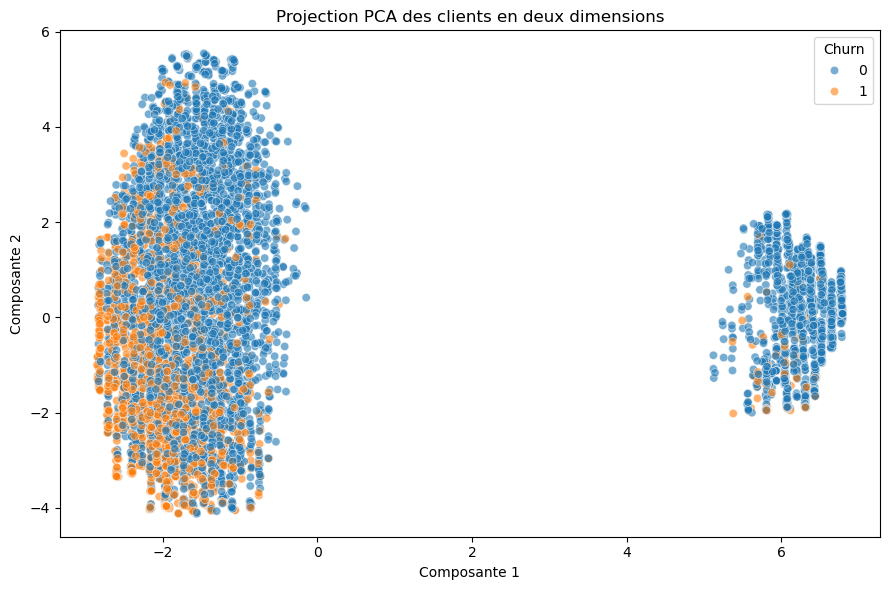

In [291]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_pca,
    x="Composante 1",
    y="Composante 2",
    hue="Churn",
    alpha=0.6
)

plt.title(
    "Projection PCA des clients en deux dimensions"
)

plt.tight_layout()
plt.show()

#### Nombre de composantes pour conserver 90 % de la variance

In [292]:
pca_complete = PCA()

pca_complete.fit(
    X_pca_scaled
)

variance_cumulee = np.cumsum(
    pca_complete.explained_variance_ratio_
)

nombre_composantes_90 = (
    np.argmax(
        variance_cumulee >= 0.90
    )
    + 1
)

print(
    "Nombre de composantes nécessaires "
    "pour conserver 90 % de la variance :",
    nombre_composantes_90
)

print(
    "Variance expliquée par les deux premières composantes :",
    round(
        pca_2d.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

Nombre de composantes nécessaires pour conserver 90 % de la variance : 16
Variance expliquée par les deux premières composantes : 41.3 %


### Test ultime avec .fit() et .predict()

In [293]:
X_final = df_phase5.drop(
    columns=["Churn"]
)

y_final = df_phase5["Churn"]

X_train_final, X_test_final, y_train_final, y_test_final = (
    train_test_split(
        X_final,
        y_final,
        test_size=0.20,
        random_state=42,
        stratify=y_final
    )
)

print(
    "Train :",
    X_train_final.shape
)

print(
    "Test :",
    X_test_final.shape
)

Train : (5634, 39)
Test : (1409, 39)


### Effectuer le test final

In [296]:
pipeline_final = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modele",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Entraîner le pipeline
pipeline_final.fit(
    X_train_final,
    y_train_final
)

# Effectuer les prédictions
predictions_finales = pipeline_final.predict(
    X_test_final
)

accuracy_finale = accuracy_score(
    y_test_final,
    predictions_finales
)

assert len(predictions_finales) == len(
    y_test_final
)

assert len(
    X_final.select_dtypes(
        exclude=["number"]
    ).columns
) == 0

assert X_final.isna().sum().sum() == 0

print("Dataset entièrement numérique : oui")
print("Valeurs manquantes restantes : 0")




Dataset entièrement numérique : oui
Valeurs manquantes restantes : 0
